# День 08. Упражнение 02
# Мульти-классовая классификация. One-hot кодирование. Случайный лес

## 0. Импорты

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import warnings

In [2]:
pd.set_option('display.max_columns', None)

## 1. Предобработка


1. Прочитай файл [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).
2. Создай DataFrame `df` с колонками: `uid`, `labname`, `numTrials`, `hour`, `dayofweek`, где `hour` извлекается из `timestamp`, а также `dayofweek` (`0` — понедельник, `6` — воскресенье). Мы будем пытаться предсказать день недели, имея данные о том, какой пользователь сделал коммит, для какой лабораторной, в какой час и с какой попытки.
3. С помощью `OneHotEncoder()` преобразуй категориальные признаки, затем удали из DataFrame исходные столбцы.
4. Используй `StandardScaler()` и нормализуй числовые признаки.
5. Сохрани DataFrame как `dayofweek.csv`.
6. Перед тем как пробовать разные алгоритмы, вычисли точность наивного алгоритма — того, который предсказывает всё как самый частый класс.


In [3]:
df = pd.read_csv('../data/checker_submits.csv', parse_dates = ['timestamp'])
df.head()

,uid,labname,numTrials,timestamp
0,user_4,project1,1,2020-04-17 05:19:02.744528
1,user_4,project1,2,2020-04-17 05:22:45.549397
2,user_4,project1,3,2020-04-17 05:34:24.422370
3,user_4,project1,4,2020-04-17 05:43:27.773992
4,user_4,project1,5,2020-04-17 05:46:32.275104


In [4]:
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df.drop(columns=['timestamp'], inplace=True)

df.head()

,uid,labname,numTrials,hour,dayofweek
0,user_4,project1,1,5,4
1,user_4,project1,2,5,4
2,user_4,project1,3,5,4
3,user_4,project1,4,5,4
4,user_4,project1,5,5,4


In [5]:
encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df[['uid', 'labname']])
df_encoded=pd.DataFrame(
    encoded,
    columns = encoder.get_feature_names_out(['uid', 'labname'])
)

df.drop(columns=['uid', 'labname'], inplace=True)
df = pd.concat([df.reset_index(drop=True), df_encoded], axis=1)

df.head()

,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,uid_user_15,uid_user_16,uid_user_17,uid_user_18,uid_user_19,uid_user_2,uid_user_20,uid_user_21,uid_user_22,uid_user_23,uid_user_24,uid_user_25,uid_user_26,uid_user_27,uid_user_28,uid_user_29,uid_user_3,uid_user_30,uid_user_31,uid_user_4,uid_user_6,uid_user_7,uid_user_8,labname_code_rvw,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,1,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,5,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [6]:
num_cols = ['numTrials', 'hour']

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()

,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,uid_user_15,uid_user_16,uid_user_17,uid_user_18,uid_user_19,uid_user_2,uid_user_20,uid_user_21,uid_user_22,uid_user_23,uid_user_24,uid_user_25,uid_user_26,uid_user_27,uid_user_28,uid_user_29,uid_user_3,uid_user_30,uid_user_31,uid_user_4,uid_user_6,uid_user_7,uid_user_8,labname_code_rvw,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,-0.788667,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.756764,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.724861,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.692958,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.661055,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1686 entries, 0 to 1685
Data columns (total 44 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   numTrials         1686 non-null   float64
 1   hour              1686 non-null   float64
 2   dayofweek         1686 non-null   int32  
 3   uid_user_0        1686 non-null   float64
 4   uid_user_1        1686 non-null   float64
 5   uid_user_10       1686 non-null   float64
 6   uid_user_11       1686 non-null   float64
 7   uid_user_12       1686 non-null   float64
 8   uid_user_13       1686 non-null   float64
 9   uid_user_14       1686 non-null   float64
 10  uid_user_15       1686 non-null   float64
 11  uid_user_16       1686 non-null   float64
 12  uid_user_17       1686 non-null   float64
 13  uid_user_18       1686 non-null   float64
 14  uid_user_19       1686 non-null   float64
 15  uid_user_2        1686 non-null   float64
 16  uid_user_20       1686 non-null   float64
 17  uid_us

In [8]:
df.to_csv('../data/dayofweek.csv', index=False)

In [9]:
print(f'Мода для таргета: {df['dayofweek'].mode()[0]}')

Мода для таргета: 3


In [10]:
naive_predict = [df['dayofweek'].mode()[0]] * len(df)
print(f'Accuracy для наивного предсказания: {accuracy_score(df['dayofweek'], naive_predict)}')

Accuracy для наивного предсказания: 0.23487544483985764


## 2. Алгоритмы


### a. Логистическая регрессия

1. Обучи логистическую регрессию; для базовой модели используй `random_state=21`, `fit_intercept=False`.
2. Вычисли точность (accuracy).
3. Напиши функцию, которая строит график (`barh`), принимая коэффициенты обученной модели, имена признаков и количество `top-n` наиболее важных признаков для отображения.
4. Построй график (`barh`) для базовой модели с 10 самыми важными признаками (по абсолютному значению) для обученной модели.
5. Помни, что это мульти-классовая классификация, и `coef_` возвращает матрицу — чтобы вычислить важность признака, нужно просуммировать все индивидуальные значения важности этого признака для всех целевых классов.

In [11]:
X = df.drop(columns=['dayofweek'])
y = df['dayofweek']

In [12]:
model_logreg = OneVsRestClassifier(
    LogisticRegression(random_state=21, fit_intercept=False, solver='liblinear')
)
model_logreg.fit(X, y)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...r='liblinear')
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
Name,Type,Value
"classes_ classes_: array, shape = [`n_classes`]Class labels.","ndarray[int32](7,)","[0,1,2,...,4,5,6]"
estimators_ estimators_: list of `n_classes` estimatorsEstimators used for predictions.,list,"[LogisticRegre...r='liblinear'), LogisticRegre...r='liblinear'), LogisticRegre...r='liblinear'), LogisticRegre...r='liblinear'), ...]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](43,)","['numTrials','hour','uid_user_0',...,'labname_laba06','labname_laba06s', 'labname_project1']"
label_binarizer_ label_binarizer_: LabelBinarizer objectObject used to transform multiclass labels to binary labels andvice-versa.,LabelBinarizer,LabelBinarize...e_output=True)
multilabel_ multilabel_: booleanWhether a OneVsRestClassifier is a multilabel classifier.,bool,False
n_classes_ n_classes_: intNumber of classes.,int,7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,43


In [13]:
predict_logreg = model_logreg.predict(X)
print(f'Accuracy для logreg: {accuracy_score(y, predict_logreg)}')

Accuracy для logreg: 0.6215895610913404


In [14]:
def draw_feature_importance(model, feature_names, top_n=10):
    if hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
    elif hasattr(model, 'estimators_'):
        importance = np.abs(np.array([e.coef_[0] for e in model.estimators_])).sum(axis=0)
    elif hasattr(model, 'coef_'):
        importance = np.abs(model.coef_).sum(axis=0)
    else:
        raise ValueError('Модель не поддерживается')

    top_idx = np.argsort(importance)[-top_n:][::-1]

    df_plot = pd.DataFrame({
        'feature': np.array(feature_names)[top_idx],
        'importance': importance[top_idx]
    })

    sns.set_style("whitegrid")
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.barplot(data=df_plot, x='importance', y='feature', color='thistle', ax=ax)
    ax.set_title(f'Топ-{top_n} важных признаков')
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

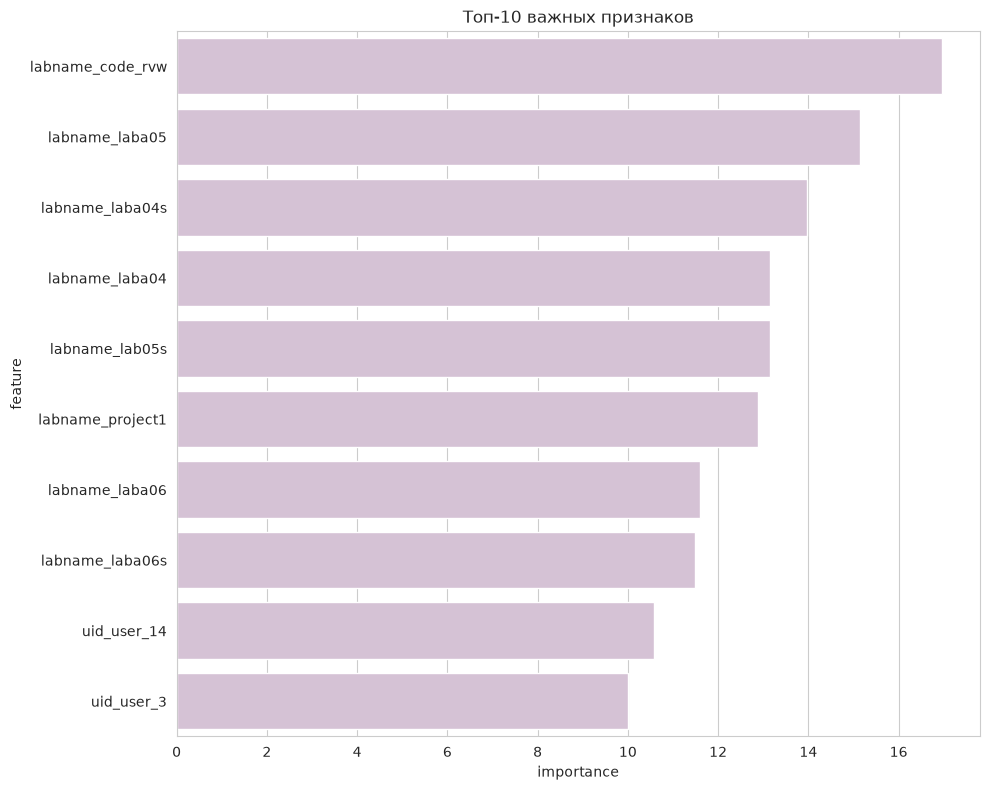

In [15]:
draw_feature_importance(model_logreg, X.columns)

### b. SVC

1. Обучи модель `SVC`; для базовой модели используй параметры `kernel='linear'`, `probability=True`, `random_state=21`.
2. Попробуй разные ядра, вычисли точности.
3. Построй график (`barh`) для базовой модели с 10 самыми важными признаками (по абсолютному значению) для обученной модели с линейным ядром.*

*По умолчанию SVC использует стратегию “one vs one” для классификации, поэтому в `coef_` возвращает матрицу. Чтобы вычислить важность признака, нужно использовать [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) поверх SVC и просуммировать все индивидуальные значения важности признака для всех целевых классов.

In [16]:
warnings.filterwarnings('ignore')

kernels = ['rbf', 'poly', 'sigmoid', 'linear']

for kernel in kernels:
    model_svc = OneVsRestClassifier(SVC(kernel=kernel, probability=True, random_state=21))
    model_svc.fit(X, y)
    predict_svc = model_svc.predict(X)
    print(f'Accuracy для kernel = {kernel}: {accuracy_score(y, predict_svc)}')

Accuracy для kernel = rbf: 0.8641755634638197


Accuracy для kernel = poly: 0.8653618030842231


Accuracy для kernel = sigmoid: 0.3499406880189798


Accuracy для kernel = linear: 0.6126927639383155


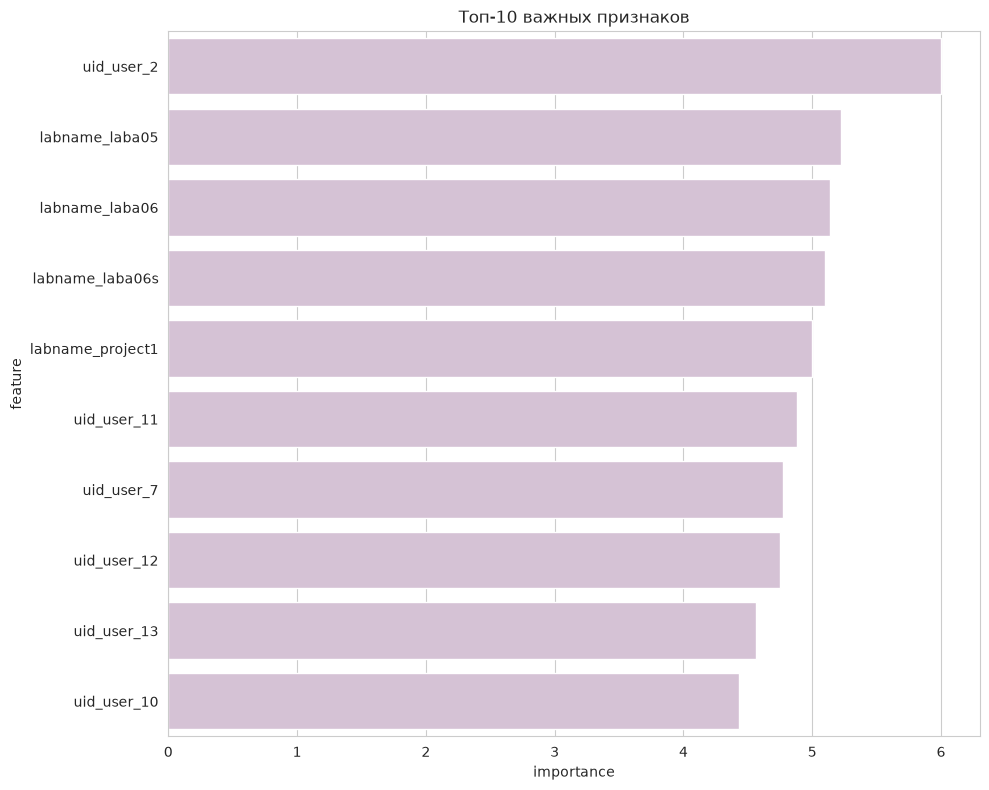

In [17]:
draw_feature_importance(model_svc, X.columns)

### c. Дерево решений

1. Обучи `DecisionTreeClassifier`; для базовой модели используй `max_depth=4`, `random_state=21`.
2. Попробуй разные значения `max_depth`, вычисли точности.
3. Построй график (`barh`) для базовой модели с 10 самыми важными признаками (по абсолютному значению) для обученной модели, используя написанную функцию.

In [18]:
model_tree = DecisionTreeClassifier(max_depth=4, random_state=21)
model_tree.fit(X, y)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",21
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [19]:
for depth in range(1, 8):
    model = DecisionTreeClassifier(max_depth=depth, random_state=21)
    model.fit(X, y)
    predict = model.predict(X)
    print(f'Accuracy для max_depth = {depth}: {accuracy_score(y, predict)}')

Accuracy для max_depth = 1: 0.35765124555160144
Accuracy для max_depth = 2: 0.4389086595492289
Accuracy для max_depth = 3: 0.48991696322657174
Accuracy для max_depth = 4: 0.5516014234875445
Accuracy для max_depth = 5: 0.6109134045077106
Accuracy для max_depth = 6: 0.6637010676156584
Accuracy для max_depth = 7: 0.7064056939501779


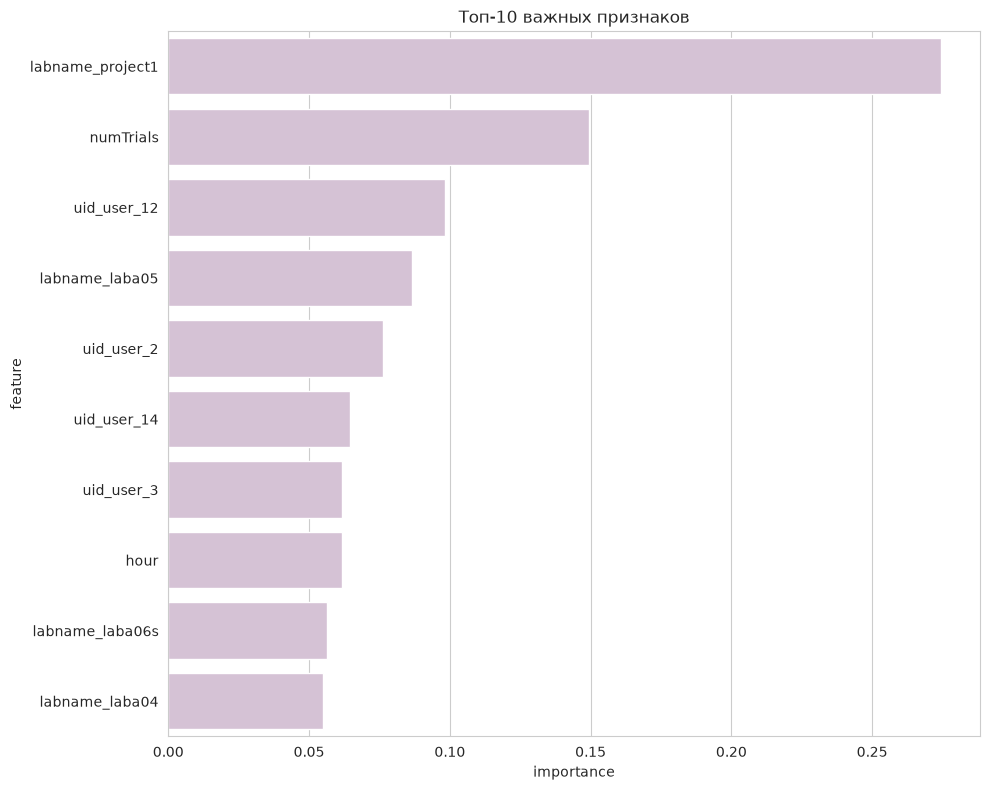

In [20]:
draw_feature_importance(model_tree, X.columns)

### d. Случайный лес

В реальной жизни лес состоит из множества деревьев. То же самое и в машинном обучении: случайный лес — это набор отдельных деревьев решений (подробнее см. документацию).

1. Обучи `RandomForestClassifier`; для базовой модели используй параметры `n_estimators=100`, `max_depth=25`, `random_state=21`.
2. Попробуй разные значения `max_depth` и `n_estimators`, вычисли точности.
3. Построй график (`barh`) для базовой модели с 10 самыми важными признаками (по абсолютному значению) для обученной модели, используя написанную функцию.

In [21]:
model_random_forest = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
model_random_forest.fit(X, y)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",25
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",21
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [22]:
for depth in [5, 10, 15, None]:
    for n_estimators in range(100, 251, 50):
        model = RandomForestClassifier(n_estimators=n_estimators, max_depth=depth, random_state=21)
        model.fit(X, y)
        predict = model.predict(X)
        print(f'Accuracy для max_depth = {depth}, n_estimators = {n_estimators}: {accuracy_score(y, predict)}')

Accuracy для max_depth = 5, n_estimators = 100: 0.5794780545670225
Accuracy для max_depth = 5, n_estimators = 150: 0.5883748517200474


Accuracy для max_depth = 5, n_estimators = 200: 0.5854092526690391


Accuracy для max_depth = 5, n_estimators = 250: 0.6020166073546857
Accuracy для max_depth = 10, n_estimators = 100: 0.8855278766310795


Accuracy для max_depth = 10, n_estimators = 150: 0.8801897983392646


Accuracy для max_depth = 10, n_estimators = 200: 0.8778173190984578


Accuracy для max_depth = 10, n_estimators = 250: 0.8795966785290629
Accuracy для max_depth = 15, n_estimators = 100: 0.9780545670225386


Accuracy для max_depth = 15, n_estimators = 150: 0.9804270462633452


Accuracy для max_depth = 15, n_estimators = 200: 0.9792408066429419


Accuracy для max_depth = 15, n_estimators = 250: 0.9810201660735468
Accuracy для max_depth = None, n_estimators = 100: 1.0


Accuracy для max_depth = None, n_estimators = 150: 1.0


Accuracy для max_depth = None, n_estimators = 200: 1.0


Accuracy для max_depth = None, n_estimators = 250: 1.0


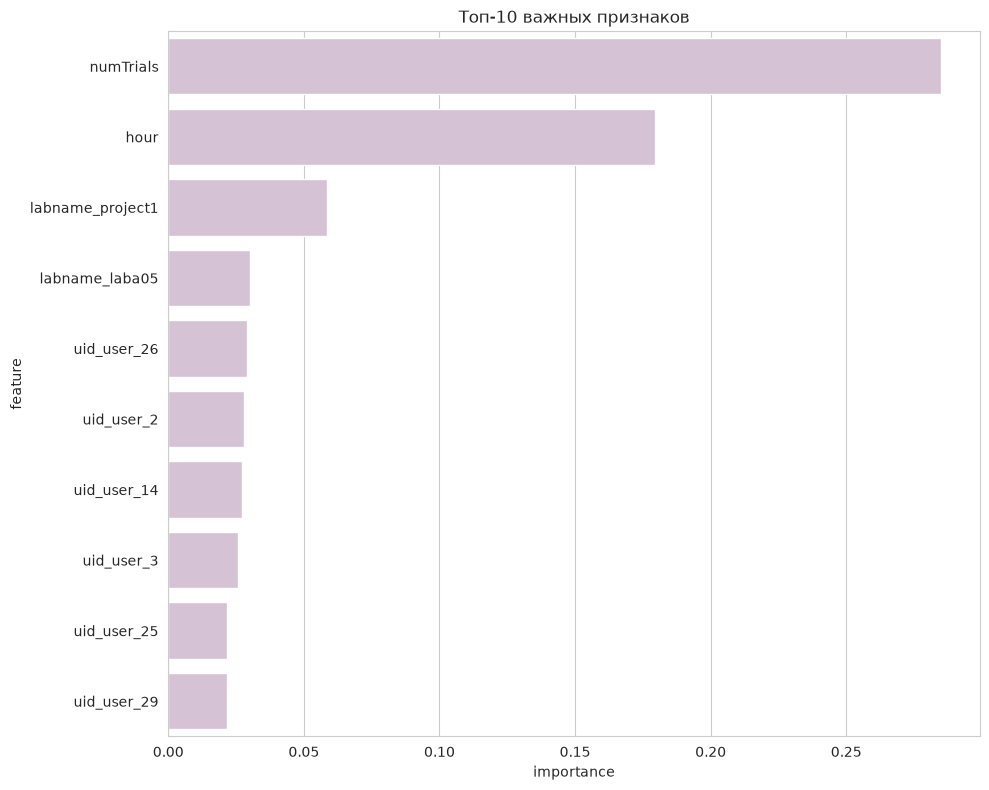

In [23]:
draw_feature_importance(model_random_forest, X.columns)